In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, auc
from sklearn.calibration import calibration_curve
import shap


/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    RocCurveDisplay
)

In [3]:

# --------------------------------------------------
# Step 1: Load dataset
# --------------------------------------------------
df = pd.read_excel("stats output/final_merged_sv_targets.xlsx")

print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())


Shape: (21225, 48)
   SUBJECT_ID  HADM_ID  VISIT_ID         MONITORTIME  SV1_min  SV1_max  \
0           4   102191         1 1981-09-25 18:40:00     67.0     95.0   
1           4   102191         1 1981-09-25 19:45:00     73.0     92.0   
2           4   102191         1 1981-09-25 20:50:00     70.0    116.0   
3           4   102191         1 1981-09-25 21:55:00     83.0     95.0   
4          37   102040         1 2071-08-12 11:00:00     70.0     99.0   

    SV1_mean  SV1_median  SV2_min  SV2_max  ...     LOS  LONG_ICU_STAY  \
0  77.461538        74.0     68.0     97.0  ...  0.5215              0   
1  80.846154        82.0     74.0     92.0  ...  0.5215              0   
2  91.461538        86.0     10.0     99.0  ...  0.5215              0   
3  88.000000        86.0     83.0     99.0  ...  0.5215              0   
4  84.928571        84.0     71.0    100.0  ...  0.7535              0   

   PAIN_SCORE  HIGH_PAIN                HOUR    HB_MEAN  HB_MIN  HB_MAX  \
0         NaN   

In [4]:
print("\nLONG_ICU_STAY distribution:")
print(df["LONG_ICU_STAY"].value_counts())

print("\nLONG_ICU_STAY percentage distribution:")
print((df["LONG_ICU_STAY"].value_counts(normalize=True) * 100).round(2))


LONG_ICU_STAY distribution:
LONG_ICU_STAY
0    10617
1    10608
Name: count, dtype: int64

LONG_ICU_STAY percentage distribution:
LONG_ICU_STAY
0    50.02
1    49.98
Name: proportion, dtype: float64


In [7]:

# --------------------------------------------------
# Step 2: Basic cleanup
# --------------------------------------------------
df.columns = [c.strip() for c in df.columns]

# Ensure target exists
if "LONG_ICU_STAY" not in df.columns:
    raise ValueError("Column 'LONG_ICU_STAY' not found in dataset.")

# Convert target to numeric if needed
df["LONG_ICU_STAY"] = pd.to_numeric(df["LONG_ICU_STAY"], errors="coerce")

# Drop rows where LONG_ICU_STAY is missing
df = df.dropna(subset=["LONG_ICU_STAY"]).copy()

# Convert target to int
df["LONG_ICU_STAY"] = df["LONG_ICU_STAY"].astype(int)

print("\nLONG_ICU_STAY distribution:")
print(df["LONG_ICU_STAY"].value_counts())



LONG_ICU_STAY distribution:
LONG_ICU_STAY
0    10617
1    10608
Name: count, dtype: int64


In [8]:

# --------------------------------------------------
# Step 3: ICD category handling
# --------------------------------------------------
if "ICD_CATEGORY" not in df.columns:
    if "ICD10_CODE_CN" in df.columns:
        df["ICD_CATEGORY"] = df["ICD10_CODE_CN"].astype(str).str[0]
        df.loc[df["ICD10_CODE_CN"].isna(), "ICD_CATEGORY"] = np.nan
    else:
        df["ICD_CATEGORY"] = np.nan

df["ICD_CATEGORY"] = df["ICD_CATEGORY"].replace(
    ["nan", "None", "NAN", ""], np.nan
)


In [9]:

# --------------------------------------------------
# Step 4: Define candidate feature columns
# --------------------------------------------------
candidate_numeric_features = [
    # SV means
    "SV1_mean", "SV2_mean", "SV3_mean", "SV4_mean", "SV5_mean", "SV6_mean", "SV7_mean",

    # SV min
    "SV1_min", "SV2_min", "SV3_min", "SV4_min", "SV5_min", "SV6_min", "SV7_min",

    # SV max
    "SV1_max", "SV2_max", "SV3_max", "SV4_max", "SV5_max", "SV6_max", "SV7_max",

    # SV median
    "SV1_median", "SV2_median", "SV3_median", "SV4_median", "SV5_median", "SV6_median", "SV7_median",

    # Hemoglobin / pain / engineered flags
    "HB_MEAN", "HB_MIN", "HB_MAX",
    "PAIN_SCORE", "HIGH_PAIN",
    "ANEMIA_FLAG", "SEVERE_ANEMIA"
]


In [10]:

# Create range features if missing
for i in range(1, 8):
    range_col = f"SV{i}_range"
    min_col = f"SV{i}_min"
    max_col = f"SV{i}_max"

    if range_col not in df.columns and min_col in df.columns and max_col in df.columns:
        df[range_col] = df[max_col] - df[min_col]

candidate_numeric_features += [f"SV{i}_range" for i in range(1, 8)]

# Keep only existing columns
numeric_features = [c for c in candidate_numeric_features if c in df.columns]

# Categorical features
categorical_features = []
if "ICD_CATEGORY" in df.columns:
    categorical_features.append("ICD_CATEGORY")


In [11]:

# --------------------------------------------------
# Step 5: Remove leakage columns
# --------------------------------------------------
leakage_cols = [
    "LOS",
    "LONG_ICU_STAY",
    "HOSPITAL_EXPIRE_FLAG"
]

numeric_features = [c for c in numeric_features if c not in leakage_cols]

print("\nNumeric features used:")
print(numeric_features)

print("\nCategorical features used:")
print(categorical_features)



Numeric features used:
['SV1_mean', 'SV2_mean', 'SV3_mean', 'SV4_mean', 'SV5_mean', 'SV6_mean', 'SV7_mean', 'SV1_min', 'SV2_min', 'SV3_min', 'SV4_min', 'SV5_min', 'SV6_min', 'SV7_min', 'SV1_max', 'SV2_max', 'SV3_max', 'SV4_max', 'SV5_max', 'SV6_max', 'SV7_max', 'SV1_median', 'SV2_median', 'SV3_median', 'SV4_median', 'SV5_median', 'SV6_median', 'SV7_median', 'HB_MEAN', 'HB_MIN', 'HB_MAX', 'PAIN_SCORE', 'HIGH_PAIN', 'ANEMIA_FLAG', 'SEVERE_ANEMIA', 'SV1_range', 'SV2_range', 'SV3_range', 'SV4_range', 'SV5_range', 'SV6_range', 'SV7_range']

Categorical features used:
['ICD_CATEGORY']


In [12]:

# --------------------------------------------------
# Step 6: Build X and y
# --------------------------------------------------
feature_cols = numeric_features + categorical_features

X = df[feature_cols].copy()
y = df["LONG_ICU_STAY"].copy()

print("\nX shape:", X.shape)
print("y distribution:")
print(y.value_counts(dropna=False))



X shape: (21225, 43)
y distribution:
LONG_ICU_STAY
0    10617
1    10608
Name: count, dtype: int64


In [13]:

# --------------------------------------------------
# Step 7: Train-test split
# --------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)



Train shape: (16980, 43)
Test shape: (4245, 43)


In [14]:

# --------------------------------------------------
# Step 8: Preprocessing
# --------------------------------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)


In [15]:
# =====================================================
# Evaluation Function
# =====================================================

results = []

def evaluate_model(model_name, sampling_method, y_test, y_pred, y_prob):
    results.append({
        "Model": model_name,
        "Sampling": sampling_method,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred)
    })

In [16]:

# --------------------------------------------------
# Step 9: Baseline Logistic Regression
# --------------------------------------------------
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        penalty="l2",
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)

y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

print("\n==============================")
print("Baseline Logistic Regression Results")
print("==============================")
print(classification_report(y_test, y_pred_lr,digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))



Baseline Logistic Regression Results
              precision    recall  f1-score   support

           0     0.6991    0.7758    0.7354      2123
           1     0.7480    0.6659    0.7046      2122

    accuracy                         0.7208      4245
   macro avg     0.7235    0.7208    0.7200      4245
weighted avg     0.7235    0.7208    0.7200      4245

Confusion Matrix:
[[1647  476]
 [ 709 1413]]
ROC-AUC: 0.7857341366470989
Accuracy: 0.7208480565371025


In [17]:
evaluate_model(
    "Logistic Regression",
    "Baseline",
    y_test,
    y_pred_lr,
    y_prob_lr
)

In [18]:

# --------------------------------------------------
# Step 10: Tuned Logistic Regression
# --------------------------------------------------
param_grid_lr = [
 # L1 regularization
    {
        "model__penalty": ["l1"],
        "model__solver": ["liblinear","saga"],
        "model__C": [0.01, 0.1, 1, 10],
        "model__max_iter": [5000]
    },

    # L2 regularization
    {
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs", "liblinear","saga"],
        "model__C": [0.01, 0.1, 1, 10],
        "model__max_iter": [5000]
    },

    # No regularization
    {
        "model__penalty": [None],
        "model__solver": ["lbfgs","saga"],
        "model__max_iter": [5000]
    }
]

grid_lr = GridSearchCV(
    estimator=log_reg_pipeline,
    param_grid=param_grid_lr,
    cv=3,
    scoring="f1",
    n_jobs=1
)

grid_lr.fit(X_train, y_train)

print("\nBest Logistic Regression Params:")
print(grid_lr.best_params_)

best_lr = grid_lr.best_estimator_

y_pred_lr_tuned = best_lr.predict(X_test)
y_prob_lr_tuned = best_lr.predict_proba(X_test)[:, 1]

print("\n==============================")
print("Tuned Logistic Regression Results")
print("==============================")
print(classification_report(y_test, y_pred_lr_tuned,digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr_tuned))
print("Accuracy:", accuracy_score(y_test, y_pred_lr_tuned))



Best Logistic Regression Params:
{'model__C': 10, 'model__max_iter': 5000, 'model__penalty': 'l2', 'model__solver': 'saga'}

Tuned Logistic Regression Results
              precision    recall  f1-score   support

           0     0.6978    0.7744    0.7341      2123
           1     0.7464    0.6645    0.7031      2122

    accuracy                         0.7194      4245
   macro avg     0.7221    0.7194    0.7186      4245
weighted avg     0.7221    0.7194    0.7186      4245

Confusion Matrix:
[[1644  479]
 [ 712 1410]]
ROC-AUC: 0.7864737583035406
Accuracy: 0.719434628975265


In [20]:
evaluate_model(
    "Logistic Regression",
    "Tuned",
    y_test,
    y_pred_lr_tuned,
    y_prob_lr_tuned
)

In [21]:

# --------------------------------------------------
# Step 11: Baseline Random Forest
# --------------------------------------------------
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("\n==============================")
print("Baseline Random Forest Results")
print("==============================")
print(classification_report(y_test, y_pred_rf,digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))



Baseline Random Forest Results
              precision    recall  f1-score   support

           0     0.7132    0.7697    0.7404      2123
           1     0.7497    0.6904    0.7188      2122

    accuracy                         0.7300      4245
   macro avg     0.7315    0.7300    0.7296      4245
weighted avg     0.7315    0.7300    0.7296      4245

Confusion Matrix:
[[1634  489]
 [ 657 1465]]
ROC-AUC: 0.8091203430139716
Accuracy: 0.7300353356890459


In [22]:
evaluate_model(
    "Random Forest",
    "Baseline",
    y_test,
    y_pred_rf,
    y_prob_rf
)

In [23]:

# --------------------------------------------------
# Step 12: Tuned Random Forest
# --------------------------------------------------
param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=3,
    scoring="f1",
    n_jobs=1
)

grid_rf.fit(X_train, y_train)

print("\nBest Random Forest Params:")
print(grid_rf.best_params_)

best_rf = grid_rf.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

print("\n==============================")
print("Tuned Random Forest Results")
print("==============================")
print(classification_report(y_test, y_pred_rf_tuned,digits=4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_tuned))
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))



Best Random Forest Params:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Tuned Random Forest Results
              precision    recall  f1-score   support

           0     0.7158    0.7748    0.7442      2123
           1     0.7545    0.6923    0.7220      2122

    accuracy                         0.7336      4245
   macro avg     0.7352    0.7336    0.7331      4245
weighted avg     0.7352    0.7336    0.7331      4245

Confusion Matrix:
[[1645  478]
 [ 653 1469]]
ROC-AUC: 0.8129238895575278
Accuracy: 0.7335689045936395


In [24]:
evaluate_model(
    "Random Forest",
    "Tuned",
    y_test,
    y_pred_rf_tuned,
    y_prob_rf_tuned
)

In [25]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["F1", "PR_AUC", "Recall"],
    ascending=False
).reset_index(drop=True)

results_df.index = results_df.index + 1

print("\nLOS MODEL RANKING")
display(results_df.round(4))


LOS MODEL RANKING


,Model,Sampling,Accuracy,Recall,Precision,F1,ROC_AUC,PR_AUC,Balanced_Accuracy,MCC
1,Random Forest,Tuned,0.7336,0.6923,0.7545,0.7220,0.8129,0.8149,0.7336,0.4687
2,Random Forest,Baseline,0.7300,0.6904,0.7497,0.7188,0.8091,0.8106,0.7300,0.4615
3,Logistic Regression,Baseline,0.7208,0.6659,0.7480,0.7046,0.7857,0.7862,0.7208,0.4444
4,Logistic Regression,Tuned,0.7194,0.6645,0.7464,0.7031,0.7865,0.7866,0.7194,0.4415
5,Logistic Regression,Tuned,0.7194,0.6645,0.7464,0.7031,0.7865,0.7866,0.7194,0.4415


In [26]:
results_df.drop_duplicates(subset=["Model", "Sampling"], keep="first", inplace=True)
display(results_df.round(4))

,Model,Sampling,Accuracy,Recall,Precision,F1,ROC_AUC,PR_AUC,Balanced_Accuracy,MCC
1,Random Forest,Tuned,0.7336,0.6923,0.7545,0.7220,0.8129,0.8149,0.7336,0.4687
2,Random Forest,Baseline,0.7300,0.6904,0.7497,0.7188,0.8091,0.8106,0.7300,0.4615
3,Logistic Regression,Baseline,0.7208,0.6659,0.7480,0.7046,0.7857,0.7862,0.7208,0.4444
4,Logistic Regression,Tuned,0.7194,0.6645,0.7464,0.7031,0.7865,0.7866,0.7194,0.4415


In [27]:
# =====================================================
# Probability Threshold Study for LOS Prediction
# Best baseline model: Tuned Random Forest
# =====================================================

import numpy as np

thresholds = np.arange(0.30, 0.71, 0.01)

threshold_results_los = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_rf_tuned >= threshold).astype(int)

    threshold_results_los.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "F1": f1_score(y_test, y_pred_threshold),
        "ROC_AUC": roc_auc_score(y_test, y_prob_rf_tuned),
        "PR_AUC": average_precision_score(y_test, y_prob_rf_tuned),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred_threshold),
        "MCC": matthews_corrcoef(y_test, y_pred_threshold)
    })

threshold_df_los = pd.DataFrame(threshold_results_los)

threshold_df_los = threshold_df_los.sort_values(
    by=["F1", "Balanced_Accuracy", "MCC"],
    ascending=False
).reset_index(drop=True)

threshold_df_los.index = threshold_df_los.index + 1

print("\nLOS THRESHOLD TUNING RESULTS - TUNED RANDOM FOREST")
display(threshold_df_los.round(4))


LOS THRESHOLD TUNING RESULTS - TUNED RANDOM FOREST


,Threshold,Accuracy,Recall,Precision,F1,ROC_AUC,PR_AUC,Balanced_Accuracy,MCC
1,0.35,0.7062,0.8770,0.6537,0.7490,0.8129,0.8149,0.7063,0.4389
2,0.37,0.7126,0.8516,0.6663,0.7476,0.8129,0.8149,0.7126,0.4427
3,0.40,0.7246,0.8148,0.6902,0.7474,0.8129,0.8149,0.7246,0.4568
4,0.38,0.7164,0.8388,0.6737,0.7473,0.8129,0.8149,0.7164,0.4464
5,0.39,0.7204,0.8252,0.6821,0.7469,0.8129,0.8149,0.7204,0.4508
6,0.41,0.7272,0.8035,0.6971,0.7465,0.8129,0.8149,0.7272,0.4598
7,0.36,0.7067,0.8629,0.6575,0.7463,0.8129,0.8149,0.7068,0.4352
8,0.42,0.7307,0.7908,0.7059,0.7459,0.8129,0.8149,0.7308,0.4649
9,0.43,0.7340,0.7809,0.7139,0.7459,0.8129,0.8149,0.7341,0.4702
10,0.34,0.6978,0.8850,0.6438,0.7454,0.8129,0.8149,0.6978,0.4266


In [30]:
# =====================================================
# Add Best LOS Threshold Model to Ranking Table
# =====================================================

best_los_threshold = threshold_df_los.iloc[0]["Threshold"]

y_pred_rf_tuned_threshold_los = (
    y_prob_rf_tuned >= best_los_threshold
).astype(int)

evaluate_model(
    "Random Forest",
    f"Tuned + Threshold {best_los_threshold:.2f}",
    y_test,
    y_pred_rf_tuned_threshold_los,
    y_prob_rf_tuned
)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["F1", "PR_AUC", "Recall"],
    ascending=False
).reset_index(drop=True)

results_df.index = results_df.index + 1
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned_threshold_los))
print("\nFINAL LOS MODEL RANKING AFTER THRESHOLD STUDY")
display(results_df.round(4))

Confusion Matrix:
[[1137  986]
 [ 261 1861]]

FINAL LOS MODEL RANKING AFTER THRESHOLD STUDY


,Model,Sampling,Accuracy,Recall,Precision,F1,ROC_AUC,PR_AUC,Balanced_Accuracy,MCC
1,Random Forest,Tuned + Threshold 0.35,0.7062,0.8770,0.6537,0.7490,0.8129,0.8149,0.7063,0.4389
2,Random Forest,Tuned + Threshold 0.35,0.7062,0.8770,0.6537,0.7490,0.8129,0.8149,0.7063,0.4389
3,Random Forest,Tuned,0.7336,0.6923,0.7545,0.7220,0.8129,0.8149,0.7336,0.4687
4,Random Forest,Baseline,0.7300,0.6904,0.7497,0.7188,0.8091,0.8106,0.7300,0.4615
5,Logistic Regression,Baseline,0.7208,0.6659,0.7480,0.7046,0.7857,0.7862,0.7208,0.4444
6,Logistic Regression,Tuned,0.7194,0.6645,0.7464,0.7031,0.7865,0.7866,0.7194,0.4415
7,Logistic Regression,Tuned,0.7194,0.6645,0.7464,0.7031,0.7865,0.7866,0.7194,0.4415


In [29]:
best_los_model = results_df.iloc[0]

print("\nBEST LOS MODEL")
print("-" * 50)

for col, value in best_los_model.items():
    print(f"{col}: {value}")


BEST LOS MODEL
--------------------------------------------------
Model: Random Forest
Sampling: Tuned + Threshold 0.35
Accuracy: 0.7062426383981154
Recall: 0.8770028275212064
Precision: 0.6536705303828592
F1: 0.7490440732541759
ROC_AUC: 0.8129238895575278
PR_AUC: 0.81494119512792
Balanced_Accuracy: 0.706282855117174
MCC: 0.43892821310668473


<Figure size 700x500 with 0 Axes>

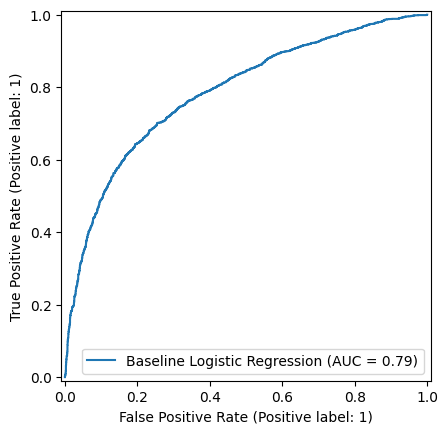

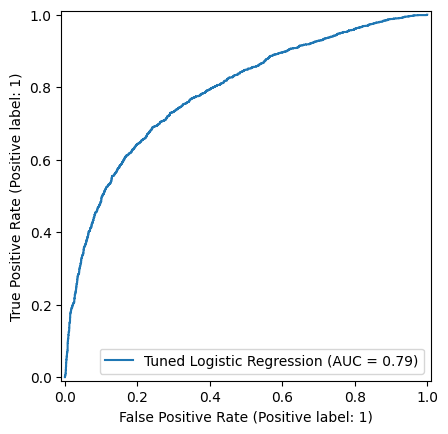

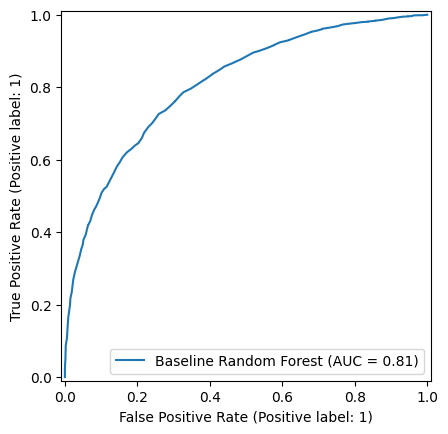

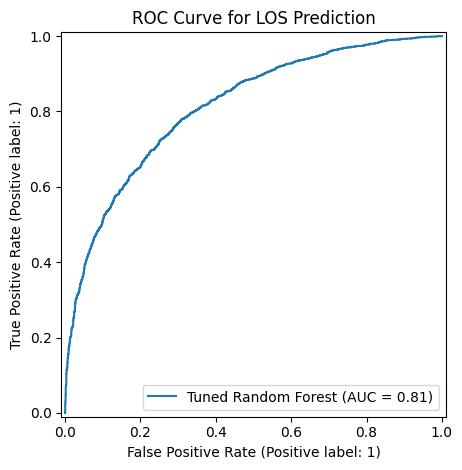

In [52]:

# --------------------------------------------------
# Step 13: ROC Curves
# --------------------------------------------------
plt.figure(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name="Baseline Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_lr_tuned, name="Tuned Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Baseline Random Forest")
RocCurveDisplay.from_predictions(y_test, y_prob_rf_tuned, name="Tuned Random Forest")
plt.title("ROC Curve for LOS Prediction")
plt.tight_layout()
plt.show()



Top 15 Important Features:
            feature  importance
9      num__SV3_min    0.046512
6     num__SV7_mean    0.040878
2     num__SV3_mean    0.039770
23  num__SV3_median    0.038623
3     num__SV4_mean    0.037933
10     num__SV4_min    0.035384
1     num__SV2_mean    0.034773
0     num__SV1_mean    0.034654
15     num__SV2_max    0.033012
21  num__SV1_median    0.032830
14     num__SV1_max    0.032313
4     num__SV5_mean    0.032143
7      num__SV1_min    0.030752
22  num__SV2_median    0.030302
35   num__SV1_range    0.029053


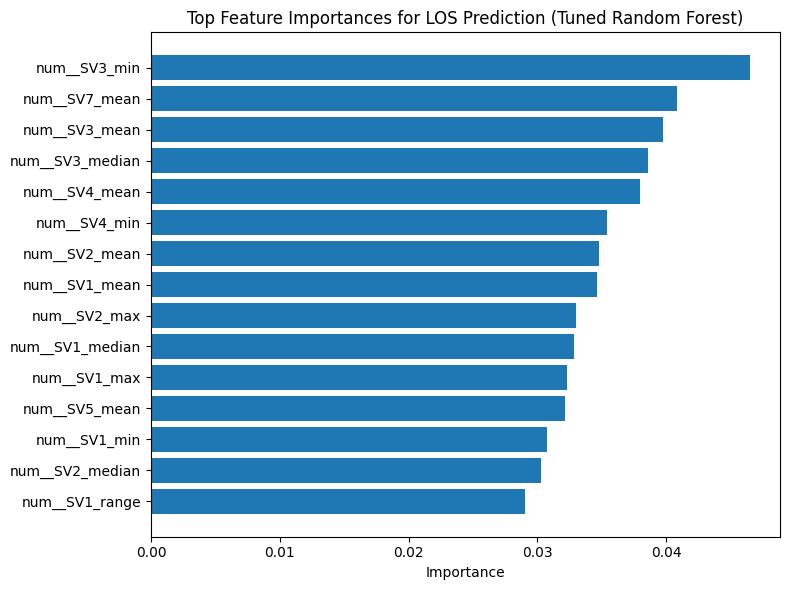

In [53]:

# --------------------------------------------------
# Step 14: Tuned Random Forest feature importance
# --------------------------------------------------
fitted_preprocessor = best_rf.named_steps["preprocessor"]
fitted_model = best_rf.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_model.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 15 Important Features:")
print(importance_df.head(15))

top_n = 15
top_importance = importance_df.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_importance["feature"], top_importance["importance"])
plt.title("Top Feature Importances for LOS Prediction (Tuned Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [37]:

# --------------------------------------------------
# Step 15: Save outputs (optional)
# --------------------------------------------------
results_df = X_test.copy()
results_df["actual_LONG_ICU_STAY"] = y_test.values
results_df["pred_lr"] = y_pred_lr
results_df["prob_lr"] = y_prob_lr
results_df["pred_lr_tuned"] = y_pred_lr_tuned
results_df["prob_lr_tuned"] = y_prob_lr_tuned
results_df["pred_rf"] = y_pred_rf
results_df["prob_rf"] = y_prob_rf
results_df["pred_rf_tuned"] = y_pred_rf_tuned
results_df["prob_rf_tuned"] = y_prob_rf_tuned

results_df.to_csv("los_prediction_results.csv", index=False)
importance_df.to_csv("los_feature_importance.csv", index=False)

print("\nSaved:")
print("- los_prediction_results.csv")
print("- los_feature_importance.csv")


Saved:
- los_prediction_results.csv
- los_feature_importance.csv


Model Reliability & Interpretability Analysis

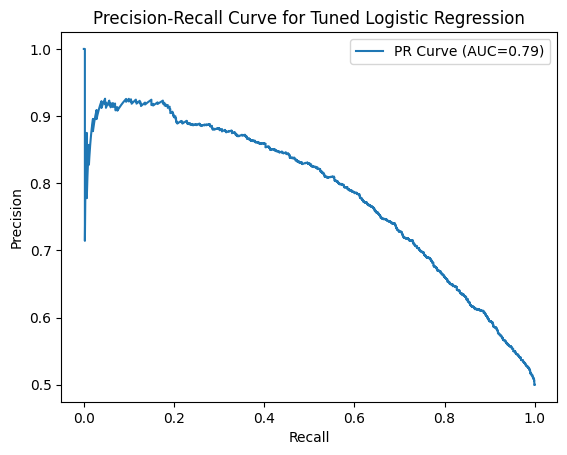

In [58]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_lr_tuned)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f"PR Curve (AUC={pr_auc:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Tuned Logistic Regression")
plt.legend()
plt.show()

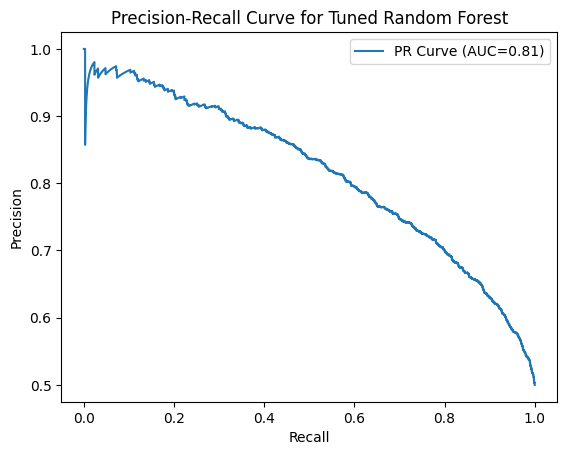

In [59]:
precision, recall, _ = precision_recall_curve(y_test, y_prob_rf_tuned)
pr_auc = auc(recall, precision)

plt.figure()
plt.plot(recall, precision, label=f"PR Curve (AUC={pr_auc:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Tuned Random Forest")
plt.legend()
plt.show()

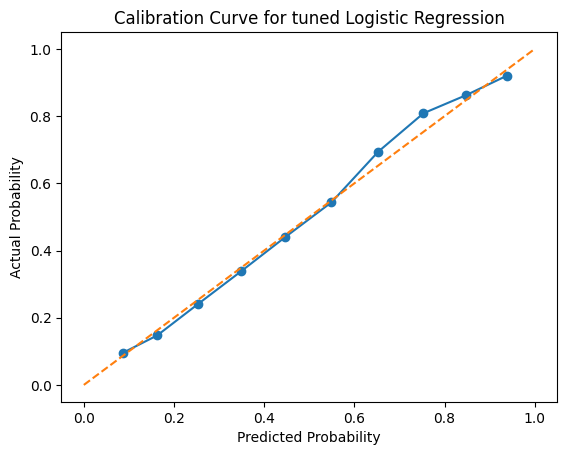

In [63]:
prob_true, prob_pred = calibration_curve(y_test, y_prob_lr_tuned, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve for tuned Logistic Regression")
plt.show()

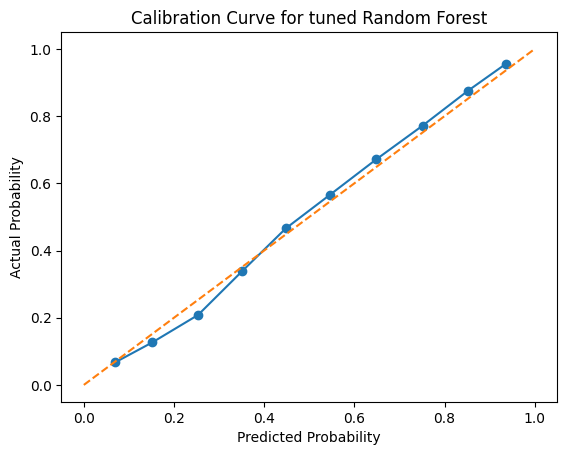

In [61]:
prob_true, prob_pred = calibration_curve(y_test, y_prob_rf_tuned, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.title("Calibration Curve for tuned Random Forest")
plt.show()

Final conclusion Comparison plot

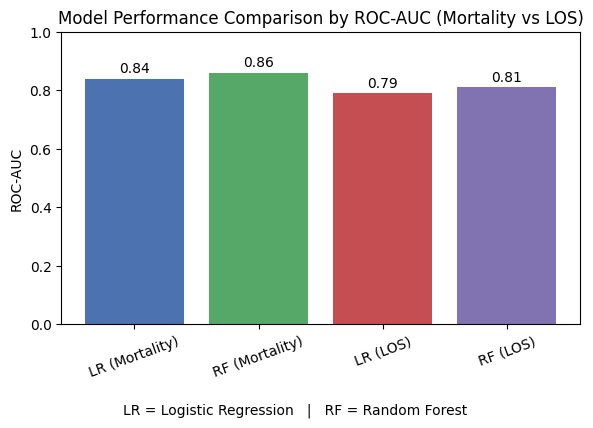

In [72]:
models = [
    "LR (Mortality)", "RF (Mortality)",
    "LR (LOS)", "RF (LOS)"
]

auc_scores = [0.84, 0.86, 0.79, 0.81]

# 🎨 Custom colors (each bar different)
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

plt.figure(figsize=(6,4))
bars = plt.bar(models, auc_scores, color=colors)

plt.ylabel("ROC-AUC")
plt.title("Model Performance Comparison by ROC-AUC (Mortality vs LOS)")
plt.xticks(rotation=20)
plt.ylim(0, 1)

# Add values on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}",
        ha='center',
        va='bottom',
    )

plt.tight_layout()
plt.figtext(
    0.5, -0.05,
    "LR = Logistic Regression   |   RF = Random Forest",
    ha="center",
    fontsize=10
)
plt.show()

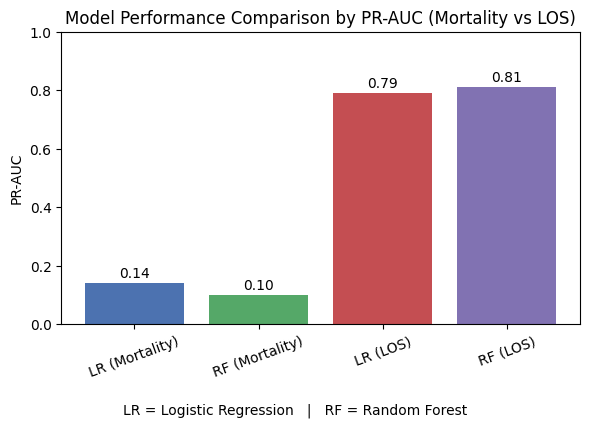

In [73]:

models = [
    "LR (Mortality)", "RF (Mortality)",
    "LR (LOS)", "RF (LOS)"
]

pr_scores = [0.14, 0.10, 0.79, 0.81]

# 🎨 Custom colors (each bar different)
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

plt.figure(figsize=(6,4))
bars = plt.bar(models, pr_scores, color=colors)

plt.ylabel("PR-AUC")
plt.title("Model Performance Comparison by PR-AUC (Mortality vs LOS)")
plt.xticks(rotation=20)
plt.ylim(0, 1)

# Add values on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}",
        ha='center',
        va='bottom',
    )

plt.tight_layout()
plt.figtext(
    0.5, -0.05,
    "LR = Logistic Regression   |   RF = Random Forest",
    ha="center",
    fontsize=10
)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")

# Diagonal line
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

SHAP Analysis

In [74]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 556.6/556.6 kB 8.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 35.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 60.9 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [shap]5/6 [shap]]te]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip


In [31]:
def run_shap_analysis(model_pipeline, X_test, model_name,
                      max_display=15, sample_size=500):

    # Extract components
    preprocessor = model_pipeline.named_steps["preprocessor"]
    model = model_pipeline.named_steps["model"]

    # Transform test data
    X_transformed = preprocessor.transform(X_test)

    if hasattr(X_transformed, "toarray"):
        X_transformed = X_transformed.toarray()

    # ==========================
    # Clinical feature mappings
    # ==========================

    feature_names = preprocessor.get_feature_names_out()

    def clean_feature_name(name):

        name = name.replace("num__", "").replace("cat__", "")

        sv_mapping = {
            "SV1": "Heart Rate",
            "SV2": "Pulse",
            "SV3": "Systolic BP",
            "SV4": "Diastolic BP",
            "SV5": "Central Venous Pressure",
            "SV6": "Respiratory Rate",
            "SV7": "Oxygen Saturation"
        }

        stat_mapping = {
            "mean": "Mean",
            "median": "Median",
            "min": "Min",
            "max": "Max",
            "range": "Range"
        }

        for sv, clinical_name in sv_mapping.items():

            if name.startswith(sv + "_"):

                stat = name.replace(sv + "_", "")
                stat = stat_mapping.get(stat, stat)

                return f"{clinical_name} ({stat})"

        if name.startswith("ICD_CATEGORY_"):

            diagnosis = name.replace("ICD_CATEGORY_", "")
            return f"{diagnosis} Diagnosis"

        return name

    feature_names = [
        clean_feature_name(col)
        for col in feature_names
    ]

    X_df = pd.DataFrame(
        X_transformed,
        columns=feature_names
    )

    # Sample for speed
    X_sample = X_df.sample(
        n=min(sample_size, len(X_df)),
        random_state=42
    )

    # ==========================
    # SHAP
    # ==========================

    if "RandomForest" in str(type(model)):

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)

        if isinstance(shap_values, list):
            shap_values_plot = shap_values[1]

        elif len(np.array(shap_values).shape) == 3:
            shap_values_plot = shap_values[:, :, 1]

        else:
            shap_values_plot = shap_values

    else:

        explainer = shap.LinearExplainer(model, X_sample)
        shap_values_plot = explainer.shap_values(X_sample)

    # Summary Plot

    plt.figure(figsize=(8, 6))

    shap.summary_plot(
        shap_values_plot,
        X_sample,
        max_display=max_display,
        show=False
    )

    plt.title(f"SHAP Summary Plot - {model_name}")
    plt.tight_layout()
    plt.show()

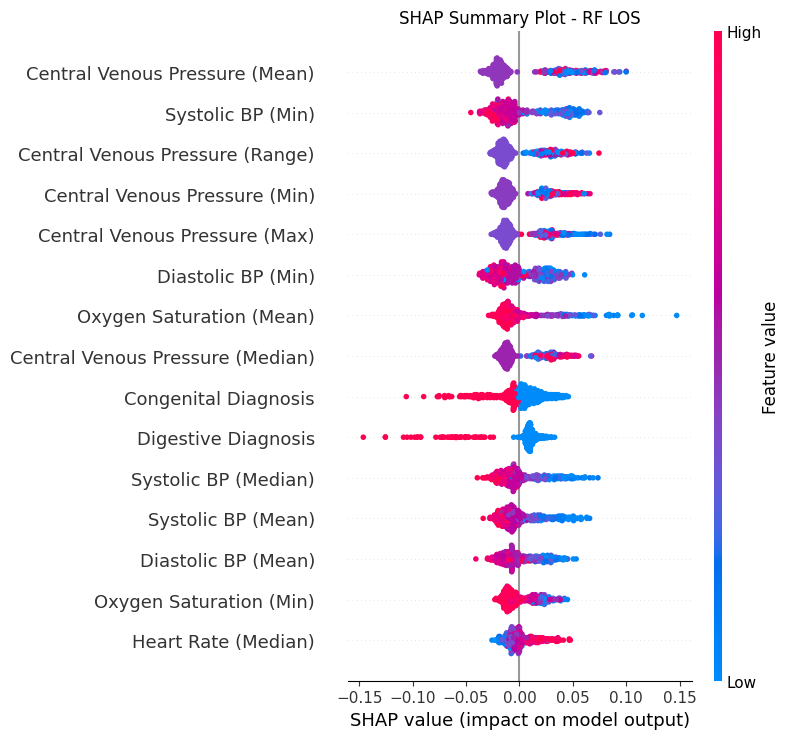

In [32]:
run_shap_analysis(best_rf, X_test, "RF LOS")


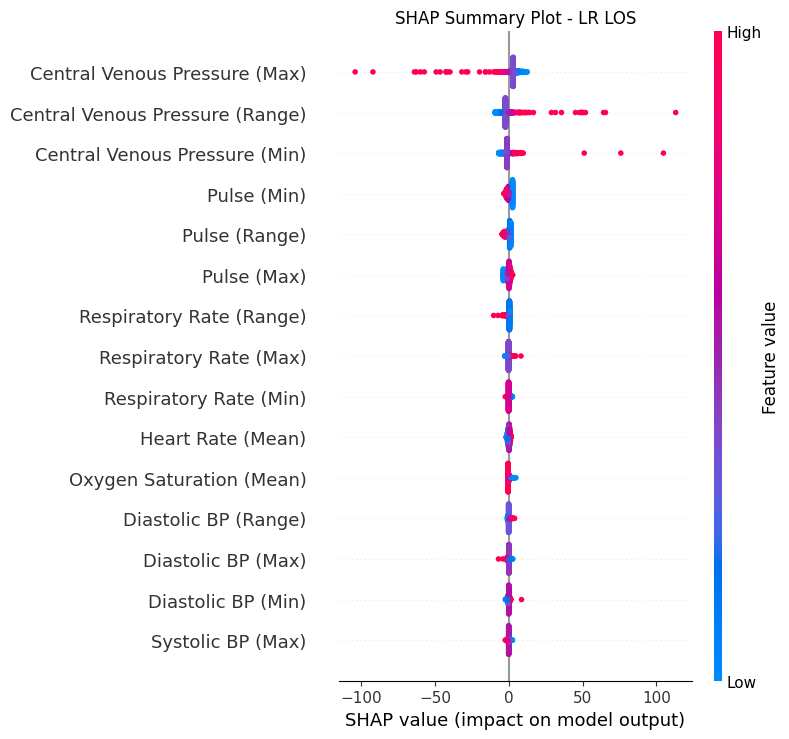

In [33]:
run_shap_analysis(best_lr, X_test, "LR LOS")